In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


def ebno_to_noise_std(
    ebno_db: float, bits_per_symbol: int, num_complex_dims: int = 1
) -> float:
  ebno_linear = 10.0 ** (ebno_db / 10.0)
  code_rate = bits_per_symbol / (2.0 * num_complex_dims)
  noise_variance = 1.0 / (2.0 * code_rate * ebno_linear)
  return np.sqrt(noise_variance)


class AWGNChannel(nn.Module):

  def forward(self, x: torch.Tensor, noise_std: float) -> torch.Tensor:
    return x + torch.randn_like(x) * noise_std


class RayleighChannel(nn.Module):

  def forward(self, x: torch.Tensor, noise_std: float, return_csi: bool = False):
    batch_size, device = x.shape[0], x.device
    h_r = torch.randn(batch_size, 1, device=device) * np.sqrt(0.5)
    h_i = torch.randn(batch_size, 1, device=device) * np.sqrt(0.5)
    x_i, x_q = x[:, 0:1], x[:, 1:2]
    y_i = h_r * x_i - h_i * x_q
    y_q = h_i * x_i + h_r * x_q
    y_faded = torch.cat([y_i, y_q], dim=1)
    y_received = y_faded + torch.randn_like(y_faded) * noise_std
    if return_csi:
      return y_received, torch.cat([h_r, h_i], dim=1)
    return y_received


class Transmitter(nn.Module):

  def __init__(self, num_symbols: int = 16, channel_dims: int = 2):
    super().__init__()
    self.M = num_symbols
    self.fc1 = nn.Linear(self.M, 32)
    self.fc2 = nn.Linear(32, 32)
    self.fc3 = nn.Linear(32, channel_dims)

  def forward(self, s_onehot: torch.Tensor) -> torch.Tensor:
    x = F.relu(self.fc1(s_onehot))
    x = F.relu(self.fc2(x))
    x_raw = self.fc3(x)
    energy = torch.mean(torch.sum(x_raw**2, dim=1, keepdim=True))
    return x_raw / torch.sqrt(energy)


class Receiver(nn.Module):

  def __init__(
      self, num_symbols: int = 16, channel_dims: int = 2, use_csi: bool = False
  ):
    super().__init__()
    self.use_csi = use_csi
    input_dim = channel_dims * 2 if use_csi else channel_dims
    self.fc1 = nn.Linear(input_dim, 32)
    self.fc2 = nn.Linear(32, 32)
    self.fc3 = nn.Linear(32, num_symbols)

  def forward(self, y: torch.Tensor, h: torch.Tensor = None) -> torch.Tensor:
    inp = torch.cat([y, h], dim=1) if (self.use_csi and h is not None) else y
    x = F.relu(self.fc1(inp))
    x = F.relu(self.fc2(x))
    return self.fc3(x)


class EndToEndAutoencoder(nn.Module):

  def __init__(
      self, num_symbols: int = 16, channel_dims: int = 2, use_csi: bool = False
  ):
    super().__init__()
    self.M = num_symbols
    self.transmitter = Transmitter(num_symbols, channel_dims)
    self.receiver = Receiver(num_symbols, channel_dims, use_csi)

  def encode(self, symbols: torch.Tensor) -> torch.Tensor:
    one_hot = F.one_hot(symbols, num_classes=self.M).float()
    return self.transmitter(one_hot)

  def decode(self, y: torch.Tensor, h: torch.Tensor = None) -> torch.Tensor:
    return self.receiver(y, h)


def train_awgn(
    model,
    epochs=40,
    batch_size=1024,
    lr=0.001,
    ebno_db_min=3.0,
    ebno_db_max=10.0,
):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model, channel = model.to(device), AWGNChannel().to(device)
  optimizer, criterion = torch.optim.Adam(
      model.parameters(), lr=lr
  ), nn.CrossEntropyLoss()
  history = []
  bits_per_symbol = int(np.log2(model.M))

  print(f"--- Entrenando Autoencoder en Canal AWGN ({device}) ---")
  for epoch in range(1, epochs + 1):
    model.train()
    loader = DataLoader(
        TensorDataset(
            torch.randint(0, model.M, (batch_size * 20,), device=device)
        ),
        batch_size=batch_size,
        shuffle=True,
    )
    total_loss = 0.0
    for (s,) in loader:
      optimizer.zero_grad()
      ebno_db = torch.empty(1).uniform_(ebno_db_min, ebno_db_max).item()
      noise_std = ebno_to_noise_std(ebno_db, bits_per_symbol)
      loss = criterion(model.decode(channel(model.encode(s), noise_std)), s)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    history.append(avg_loss)
    if epoch % 10 == 0 or epoch == 1:
      print(f"Época [{epoch}/{epochs}] - Loss Cross-Entropy: {avg_loss:.5f}")
  return history


def train_rayleigh(
    model,
    epochs=50,
    batch_size=1024,
    lr=0.001,
    ebno_db_min=5.0,
    ebno_db_max=15.0,
):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model, channel = model.to(device), RayleighChannel().to(device)
  optimizer, criterion = torch.optim.Adam(
      model.parameters(), lr=lr
  ), nn.CrossEntropyLoss()
  history = []
  bits_per_symbol = int(np.log2(model.M))

  print(f"\n--- Entrenando Autoencoder en Canal Rayleigh + CSI ({device}) ---")
  for epoch in range(1, epochs + 1):
    model.train()
    loader = DataLoader(
        TensorDataset(
            torch.randint(0, model.M, (batch_size * 20,), device=device)
        ),
        batch_size=batch_size,
        shuffle=True,
    )
    total_loss = 0.0
    for (s,) in loader:
      optimizer.zero_grad()
      ebno_db = torch.empty(1).uniform_(ebno_db_min, ebno_db_max).item()
      noise_std = ebno_to_noise_std(ebno_db, bits_per_symbol)
      y, h = channel(model.encode(s), noise_std, return_csi=True)
      loss = criterion(model.decode(y, h), s)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    history.append(avg_loss)
    if epoch % 10 == 0 or epoch == 1:
      print(f"Época [{epoch}/{epochs}] - Loss Cross-Entropy: {avg_loss:.5f}")
  return history

In [2]:
M = 16

# 1. Entrenar modelo en canal AWGN
model_awgn = EndToEndAutoencoder(num_symbols=M, channel_dims=2, use_csi=False)
history_awgn = train_awgn(model_awgn, epochs=40)

# 2. Entrenar modelo en canal Rayleigh
model_rayleigh = EndToEndAutoencoder(
    num_symbols=M, channel_dims=2, use_csi=True
)
history_rayleigh = train_rayleigh(model_rayleigh, epochs=50)

--- Entrenando Autoencoder en Canal AWGN (cpu) ---
Época [1/40] - Loss Cross-Entropy: 2.72069
Época [10/40] - Loss Cross-Entropy: 1.11244
Época [20/40] - Loss Cross-Entropy: 0.71415
Época [30/40] - Loss Cross-Entropy: 0.71360
Época [40/40] - Loss Cross-Entropy: 0.71231

--- Entrenando Autoencoder en Canal Rayleigh + CSI (cpu) ---
Época [1/50] - Loss Cross-Entropy: 2.77488
Época [10/50] - Loss Cross-Entropy: 2.03167
Época [20/50] - Loss Cross-Entropy: 1.31210
Época [30/50] - Loss Cross-Entropy: 1.09152
Época [40/50] - Loss Cross-Entropy: 0.97269
Época [50/50] - Loss Cross-Entropy: 0.97370


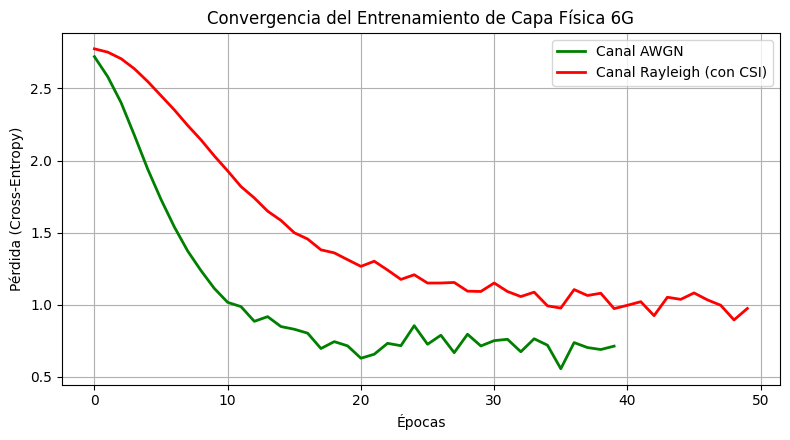

In [3]:
plt.figure(figsize=(8, 4.5))
plt.plot(history_awgn, label="Canal AWGN", color="green", linewidth=2)
plt.plot(
    history_rayleigh, label="Canal Rayleigh (con CSI)", color="red", linewidth=2
)
plt.xlabel("Épocas")
plt.ylabel("Pérdida (Cross-Entropy)")
plt.title("Convergencia del Entrenamiento de Capa Física 6G")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import os
import torch
from google.colab import files

# 1. Crear la carpeta interna en Colab
os.makedirs("models_checkpoints", exist_ok=True)

# 2. Guardar los pesos de los modelos entrenados
torch.save(model_awgn.state_dict(), "models_checkpoints/autoencoder_awgn.pth")
torch.save(
    model_rayleigh.state_dict(), "models_checkpoints/autoencoder_rayleigh.pth"
)

# 3. Descargar automáticamente los 2 archivos .pth a tu ordenador
files.download("models_checkpoints/autoencoder_awgn.pth")
files.download("models_checkpoints/autoencoder_rayleigh.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>